# Sea ice vs. open water in Sentinel-1 SAR: a first look

**Goal.** Take one Sentinel-1 Extra Wide (EW) dual-polarization (HH+HV) scene over the eastern Beaufort Sea,
turn the raw pixel values into calibrated, noise-corrected backscatter, and separate sea ice from open water
with (a) a simple threshold and (b) k-means clustering. Then check the result against an independent
sea ice concentration product.

**Scene.** `S1A_EW_GRDM_1SDH_20240502T152026_20240502T152126_053694_0685B0`, 2 May 2024, descending pass,
west coast of Banks Island (NWT, Canada). Accessed from Microsoft Planetary Computer (no account needed).

The notebook runs top to bottom. The first run reads about 40 MB from the cloud and caches it in `data/`
(gitignored); later runs only need the network for the STAC search.

**Pipeline:** find scene → subset → calibrate to σ⁰ + remove thermal noise → dB → speckle filter →
histograms → threshold and k-means classification → compare with AMSR2 sea ice concentration.

*Contains modified Copernicus Sentinel data [2024]. AMSR2 ASI sea ice concentration from the University of Bremen.*

In [1]:
from pathlib import Path
import xml.etree.ElementTree as ET

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import rasterio
from rasterio.windows import Window
import pystac_client
import planetary_computer

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data"
FIGS = ROOT / "figures"
DATA.mkdir(exist_ok=True)
FIGS.mkdir(exist_ok=True)

SCENE_ID = "S1A_EW_GRDM_1SDH_20240502T152026_20240502T152126_053694_0685B0"
POLS = ["hh", "hv"]

# Subset in radar (row, col) pixel coordinates of the full-resolution image.
# 3000 x 3000 px at 40 m spacing is ~120 x 120 km: flaw lead + pack ice, no land.
ROW0, COL0, SIZE = 2000, 4300, 3000
WINDOW = Window(col_off=COL0, row_off=ROW0, width=SIZE, height=SIZE)

plt.rcParams.update({"figure.dpi": 72, "image.interpolation": "nearest"})

## 1. Find the scene

Sentinel-1 data on Planetary Computer is indexed with **STAC** (SpatioTemporal Asset Catalog), a standard
JSON format for "what images exist, where, when". The search below is how this scene was found: EW mode,
over the Amundsen Gulf / Banks Island area, late April to mid May 2024 (cold enough that snow on the ice is still dry,
but with leads and polynyas opening). `planetary_computer.sign_inplace` adds a short-lived read token to
each file URL. No login is required.

In [2]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)
search = catalog.search(
    collections=["sentinel-1-grd"],
    intersects={"type": "Point", "coordinates": [-126.5, 70.8]},
    datetime="2024-04-15/2024-05-20",
    query={"sar:instrument_mode": {"eq": "EW"}},
)
for it in search.items():
    print(it.id, it.properties["sar:polarizations"])

item = catalog.get_collection("sentinel-1-grd").get_item(SCENE_ID)
print("\nChosen:", item.id)
print("Assets:", sorted(item.assets))

S1A_EW_GRDM_1SDH_20240507T152841_20240507T152941_053767_06888B ['HH', 'HV']
S1A_EW_GRDM_1SDH_20240504T150500_20240504T150558_053723_0686D3 ['HH', 'HV']
S1A_EW_GRDM_1SDH_20240502T152026_20240502T152126_053694_0685B0 ['HH', 'HV']
S1A_EW_GRDM_1SDH_20240427T151215_20240427T151315_053621_0682C3 ['HH', 'HV']
S1A_EW_GRDM_1SDH_20240422T150500_20240422T150558_053548_067FF3 ['HH', 'HV']
S1A_EW_GRDM_1SDH_20240420T152026_20240420T152126_053519_067ED0 ['HH', 'HV']
S1A_EW_GRDM_1SDH_20240418T153655_20240418T153755_053490_067DA3 ['HH', 'HV']
S1A_EW_GRDM_1SDH_20240415T151214_20240415T151314_053446_067BE3 ['HH', 'HV']



Chosen: S1A_EW_GRDM_1SDH_20240502T152026_20240502T152126_053694_0685B0
Assets: ['hh', 'hv', 'rendered_preview', 'safe-manifest', 'schema-calibration-hh', 'schema-calibration-hv', 'schema-noise-hh', 'schema-noise-hv', 'schema-product-hh', 'schema-product-hv', 'thumbnail', 'tilejson']


Each scene has one Cloud-Optimized GeoTIFF per polarization (`hh`, `hv`) holding raw 16-bit
**digital numbers (DN)**, plus XML annotation files. We need two of them per polarization:
`calibration-*.xml` (to turn DN into physical backscatter) and `noise-*.xml` (thermal noise estimate).

The GeoTIFFs are in **radar geometry**: rows run along the flight direction (azimuth), columns run
away from the satellite (range). There is no map projection, only ground control points (GCPs) that tie
some pixels to latitude/longitude.

In [3]:
with rasterio.open(item.assets["hh"].href) as src:
    FULL_SHAPE = (src.height, src.width)
    gcps, gcp_crs = src.gcps
    print("Full image:", FULL_SHAPE, src.dtypes[0], "| CRS:", src.crs, "| GCPs:", len(gcps), gcp_crs)
    for g in (gcps[0], gcps[20], gcps[-21], gcps[-1]):
        print(f"  pixel (row {g.row:5.0f}, col {g.col:5.0f}) -> lat {g.y:6.2f}, lon {g.x:8.2f}")

Full image: (9991, 10435) uint16 | CRS: None | GCPs: 441 EPSG:4326
  pixel (row     0, col     0) -> lat  73.71, lon  -118.36
  pixel (row     0, col 10434) -> lat  74.83, lon  -131.55
  pixel (row  9990, col     0) -> lat  70.32, lon  -122.81
  pixel (row  9990, col 10434) -> lat  71.29, lon  -133.81


## 2. Look at the whole scene, then cut a subset

Reading the whole image at full resolution would be ~100 million pixels per band. COGs store
pre-computed overviews, so we can read a reduced 1/8 version (~320 m pixels) just to look.
The values here are uncalibrated (DN², in dB), only for orientation. The red box is our subset.

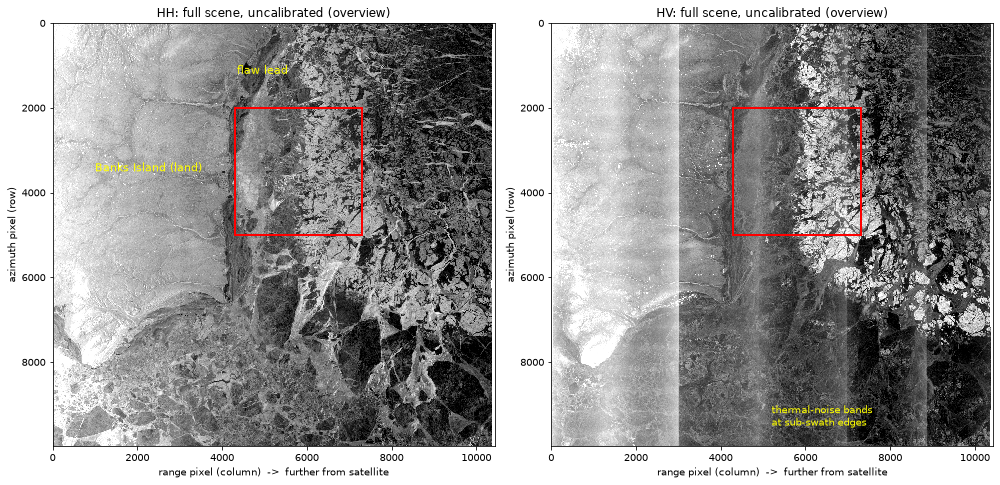

In [4]:
def read_overview(pol, factor=8):
    with rasterio.open(item.assets[pol].href) as src:
        dn = src.read(1, out_shape=(src.height // factor, src.width // factor)).astype("float32")
    return np.where(dn > 0, dn, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, pol in zip(axes, POLS):
    db = 10 * np.log10(read_overview(pol) ** 2)
    lo, hi = np.nanpercentile(db, [2, 98])
    ax.imshow(db, cmap="gray", vmin=lo, vmax=hi, extent=[0, FULL_SHAPE[1], FULL_SHAPE[0], 0])
    ax.add_patch(plt.Rectangle((COL0, ROW0), SIZE, SIZE, fill=False, ec="red", lw=2))
    ax.set_title(f"{pol.upper()}: full scene, uncalibrated (overview)")
    ax.set_xlabel("range pixel (column)  ->  further from satellite")
    ax.set_ylabel("azimuth pixel (row)")
axes[0].annotate("Banks Island (land)", (1000, 3500), color="yellow", fontsize=11)
axes[0].annotate("flaw lead", (4350, 1200), color="yellow", fontsize=11)
axes[1].annotate("thermal-noise bands\nat sub-swath edges", (5200, 9500), color="yellow", fontsize=10)
plt.tight_layout()
plt.savefig(FIGS / "01_scene_overview.png", dpi=75, bbox_inches="tight")
plt.show()

Things to notice:
- Column 0 is the **east** side (-118°), the last column is the **west** (-133°): the image is mirrored
  relative to a map because the satellite flies south (descending) and looks to its right.
- Left third = land (Banks Island). The dark strip along its coast is the **flaw lead**, the gap between
  ice frozen to the coast and the drifting pack.
- **HV shows vertical bands.** EW mode stitches its 400 km swath from 5 sub-swaths. HV is so weak that the
  instrument's own thermal noise is a visible fraction of the signal, and it changes at each sub-swath
  boundary. We remove it in Section 3.

Now read the subset at full resolution and cache it locally, together with the annotation XMLs.

In [5]:
def cached_subset(pol):
    """Read the full-resolution subset of one polarization (DN, uint16) once, then reuse the local copy."""
    path = DATA / f"{SCENE_ID}_{pol}_r{ROW0}_c{COL0}_{SIZE}.npy"
    if not path.exists():
        with rasterio.open(item.assets[pol].href) as src:
            np.save(path, src.read(1, window=WINDOW))
    return np.load(path)

def cached_xml(asset_key):
    """Download an annotation XML once and return its parsed root element."""
    path = DATA / f"{SCENE_ID}_{asset_key}.xml"
    if not path.exists():
        import urllib.request
        urllib.request.urlretrieve(item.assets[asset_key].href, path)
    return ET.parse(path).getroot()

dn = {pol: cached_subset(pol) for pol in POLS}
cal_xml = {pol: cached_xml(f"schema-calibration-{pol}") for pol in POLS}
noise_xml = {pol: cached_xml(f"schema-noise-{pol}") for pol in POLS}

for pol in POLS:
    d = dn[pol]
    print(f"{pol.upper()} DN subset: shape {d.shape}, dtype {d.dtype}, "
          f"min {d.min()}, median {np.median(d):.0f}, max {d.max()}, zeros (no data) {np.mean(d == 0):.1%}")

HH DN subset: shape (3000, 3000), dtype uint16, min 47, median 264, max 1201, zeros (no data) 0.0%
HV DN subset: shape (3000, 3000), dtype uint16, min 20, median 72, max 618, zeros (no data) 0.0%


## 3. Calibration and thermal noise removal

The GeoTIFF stores **DN**, an amplitude in arbitrary instrument units. What we want is **σ⁰ (sigma nought)**,
the radar backscatter coefficient: how much power comes back per unit ground area (unitless, m²/m²).
ESA provides everything needed in the annotation XMLs:

$$\sigma^0 = \frac{DN^2 - \text{noise}}{A_\sigma^2}$$

- $DN^2$: amplitude squared gives power.
- $A_\sigma$: calibration constant from `calibration.xml` (`sigmaNought` vectors), given on a sparse grid
  (every 40 px in range, every ~167 lines in azimuth), so we interpolate it to every pixel.
- noise: estimated thermal noise power from `noise.xml` = range profile × azimuth profile.
  Noise is additive, so it is subtracted in the power domain, before dividing by $A_\sigma^2$.

This is ESA's documented recipe (Sentinel-1 Level-1 calibration and thermal noise removal notes), the same
thing SNAP's *Calibrate* + *Thermal Noise Removal* operators do.

In [6]:
def _floats(el):
    return np.array(el.text.split(), dtype="float64")

def interp_sparse_grid(lines, pixels, values, rows, cols):
    """Bilinear interpolation of an annotation grid (vectors at `lines`, samples at `pixels`) onto rows x cols."""
    # First along range (each vector has its own pixel positions), then along azimuth.
    along_range = np.stack([np.interp(cols, p, v) for p, v in zip(pixels, values)])  # (n_vectors, n_cols)
    out = np.empty((len(rows), len(cols)))
    for j in range(len(cols)):
        out[:, j] = np.interp(rows, lines, along_range[:, j])
    return out

ROWS = np.arange(ROW0, ROW0 + SIZE)   # full-image coordinates of the subset
COLS = np.arange(COL0, COL0 + SIZE)

def calibration_lut(root):
    vecs = root.find("calibrationVectorList")
    lines = [int(v.find("line").text) for v in vecs]
    pixels = [_floats(v.find("pixel")) for v in vecs]
    values = [_floats(v.find("sigmaNought")) for v in vecs]
    return interp_sparse_grid(lines, pixels, values, ROWS, COLS)

def noise_power(root):
    # Range part: same layout as the calibration vectors.
    vecs = root.find("noiseRangeVectorList")
    lines = [int(v.find("line").text) for v in vecs]
    pixels = [_floats(v.find("pixel")) for v in vecs]
    values = [_floats(v.find("noiseRangeLut")) for v in vecs]
    noise = interp_sparse_grid(lines, pixels, values, ROWS, COLS)

    # Azimuth part: one 1-D profile per (sub-swath, azimuth block) rectangle.
    azimuth = np.ones_like(noise)
    for blk in root.find("noiseAzimuthVectorList"):
        r0, r1 = int(blk.find("firstAzimuthLine").text), int(blk.find("lastAzimuthLine").text)
        c0, c1 = int(blk.find("firstRangeSample").text), int(blk.find("lastRangeSample").text)
        rmask = (ROWS >= r0) & (ROWS <= r1)
        cmask = (COLS >= c0) & (COLS <= c1)
        if rmask.any() and cmask.any():
            profile = np.interp(ROWS[rmask], _floats(blk.find("line")), _floats(blk.find("noiseAzimuthLut")))
            azimuth[np.ix_(rmask, cmask)] = profile[:, None]
    return noise * azimuth

# After noise subtraction, pixels whose true signal is below the noise floor come out ~0 or negative.
# We KEEP those values for filtering (averaging them is unbiased) and only clip to this floor for dB conversion.
SIGMA0_FLOOR = 1e-4  # = -40 dB, well below anything Sentinel-1 EW can actually measure

sigma0, sigma0_no_nr = {}, {}
for pol in POLS:
    power = dn[pol].astype("float64") ** 2
    A2 = calibration_lut(cal_xml[pol]) ** 2
    sigma0_no_nr[pol] = power / A2                                     # calibrated, no noise removal
    nr = power - noise_power(noise_xml[pol])
    print(f"{pol.upper()}: {np.mean(nr <= 0):.2%} of pixels at or below the noise level after subtraction")
    sigma0[pol] = (nr / A2).astype("float32")                         # calibrated + noise removed (may be <= 0)

def to_db(x):
    """Linear power -> decibels, with values below SIGMA0_FLOOR clipped to the floor."""
    return 10 * np.log10(np.maximum(x, SIGMA0_FLOOR))

for pol in POLS:
    print(f"{pol.upper()} sigma0: median {np.median(to_db(sigma0[pol])):.1f} dB, "
          f"2-98% range {np.percentile(to_db(sigma0[pol]), 2):.1f} .. {np.percentile(to_db(sigma0[pol]), 98):.1f} dB")

HH: 0.00% of pixels at or below the noise level after subtraction


HV: 5.47% of pixels at or below the noise level after subtraction
HH sigma0: median -14.8 dB, 2-98% range -21.6 .. -8.7 dB


HV sigma0: median -28.8 dB, 2-98% range -40.0 .. -17.7 dB


**How close to the noise is the signal?** Dividing the noise power by $A_\sigma^2$ expresses it in σ⁰ units: the
**noise-equivalent sigma zero (NESZ)**, the weakest backscatter the instrument can distinguish from its own noise.

In [7]:
for pol in POLS:
    nesz = to_db(noise_power(noise_xml[pol]) / calibration_lut(cal_xml[pol]) ** 2)
    print(f"{pol.upper()} NESZ across subset: mean {nesz.mean():.1f} dB (range {nesz.min():.1f} to {nesz.max():.1f}) | "
          f"median signal {np.median(to_db(sigma0[pol])):.1f} dB")

HH NESZ across subset: mean -29.2 dB (range -32.0 to -25.4) | median signal -14.8 dB


HV NESZ across subset: mean -29.8 dB (range -32.6 to -25.8) | median signal -28.8 dB


HH (median ≈ -15 dB) is far above the noise floor (≈ -29.5 dB). HV (median ≈ -29 dB) sits right on it over much of the
subset: only the multi-year ice is clearly above it. This one fact explains most of the HV difficulties below.

**Did noise removal work?** The clearest test is the column-mean profile of HV: averaging down each column
smooths out the ice/water pattern and leaves anything that varies with range, like the noise pattern. The
dotted lines mark the sub-swath boundaries from `noise.xml`.

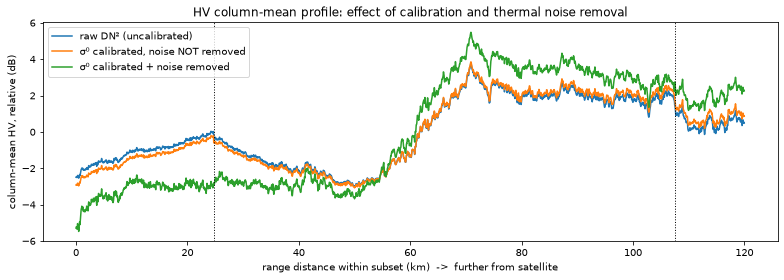

In [8]:
KM = 0.04  # 40 m pixel spacing
x_km = np.arange(SIZE) * KM
swath_edges = [4918 - COL0, 6987 - COL0]  # EW2|EW3 and EW3|EW4 boundaries for rows 2318-4999

fig, ax = plt.subplots(figsize=(11, 4))
for arr, label in [(dn["hv"].astype("float64") ** 2, "raw DN² (uncalibrated)"),
                   (sigma0_no_nr["hv"], "σ⁰ calibrated, noise NOT removed"),
                   (sigma0["hv"], "σ⁰ calibrated + noise removed")]:
    prof = to_db(arr.mean(axis=0))
    ax.plot(x_km, prof - prof.mean(), label=label)   # shifted to a common mean so shapes can be compared
for e in swath_edges:
    ax.axvline(e * KM, color="k", ls=":", lw=1)
ax.set_xlabel("range distance within subset (km)  ->  further from satellite")
ax.set_ylabel("column-mean HV, relative (dB)")
ax.set_title("HV column-mean profile: effect of calibration and thermal noise removal")
ax.legend()
plt.tight_layout()
plt.savefig(FIGS / "02_hv_noise_profile.png", dpi=110, bbox_inches="tight")
plt.show()

**Incidence angle.** The radar looks at the ground more steeply in near range and more obliquely in far range.
For the same surface, σ⁰ decreases as incidence angle increases (more energy bounces away from the sensor). We
don't correct for this, but it is worth knowing how large the effect could be across the subset.

In [9]:
# Note: on Planetary Computer the "schema-product-hh" asset points to the RFI report, not the main annotation,
# so we build the URL of the main annotation file (annotation/ew-hh.xml) from the calibration file's URL.
ann_path = DATA / f"{SCENE_ID}_annotation-hh.xml"
if not ann_path.exists():
    import urllib.request
    url = item.assets["schema-calibration-hh"].href.replace("/calibration/calibration-ew-hh.xml", "/ew-hh.xml")
    urllib.request.urlretrieve(url, ann_path)
grid = ET.parse(ann_path).getroot().find("geolocationGrid/geolocationGridPointList")
pix, line, inc = (np.array([float(p.find(k).text) for p in grid]) for k in ("pixel", "line", "incidenceAngle"))

mid_line = line[np.argmin(np.abs(line - (ROW0 + SIZE / 2)))]  # grid row closest to the subset centre
on_row = line == mid_line
inc_near, inc_far = np.interp([COL0, COL0 + SIZE], pix[on_row], inc[on_row])
print(f"Incidence angle: whole scene {inc.min():.1f}°-{inc.max():.1f}°, subset {inc_near:.1f}°-{inc_far:.1f}°")

Incidence angle: whole scene 19.2°-46.6°, subset 32.2°-39.8°


## 4. Speckle filtering

Each 40 m pixel contains many small scatterers whose echoes add up with random phases, so even a perfectly
uniform surface gives a grainy image. That is **speckle**. It is multiplicative: its strength scales with the signal.
The GRD product is already multi-looked (**ENL ≈ 10.7** from the metadata), so speckle is moderate, but visible.

We compare two simple filters, both applied to **linear σ⁰** (the speckle model is defined for intensity, and
averaging in dB would bias the result):

1. **Lee filter (7×7).** Compares local variance to what speckle alone would produce (coefficient of variation² = 1/ENL).
   Homogeneous area → output the local mean; edge or real texture → keep the original pixel. Edge-preserving.
2. **5×5 multilook (block average).** Average each 5×5 block into one 200 m pixel. Blunt, but unbiased, and it
   also averages down additive noise. Costs resolution: features narrower than ~200 m are lost.

Why both: HV here sits close to the instrument noise floor (median ≈ -29 dB). There, the remaining variation is
**additive noise**, not multiplicative speckle. Lee's speckle model doesn't apply, it sees "real texture" and leaves
those pixels unsmoothed. Multilooking doesn't depend on that model.

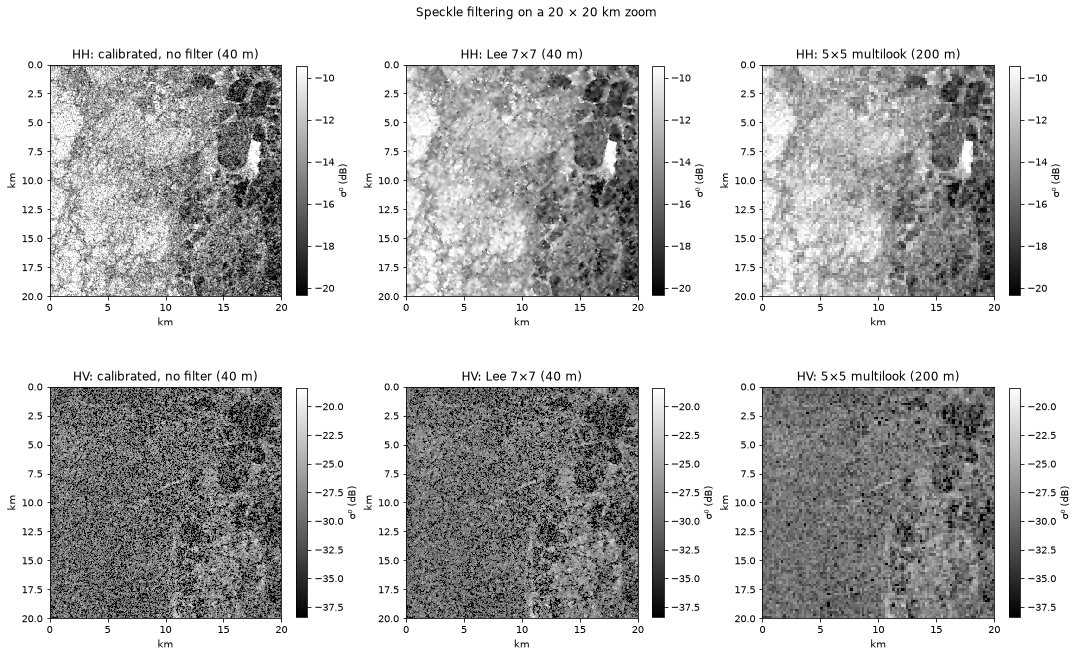

HH ENL (90th pct of 2 km blocks):  no filter   6.2  |  Lee 7×7  17.5  |  5×5 multilook  17.6
    share of pixels at the -40 dB floor: calibrated, no filter 0.0%, Lee 7×7 0.0%, 5×5 multilook 0.0%
HV ENL (90th pct of 2 km blocks):  no filter   2.2  |  Lee 7×7   3.4  |  5×5 multilook   6.9
    share of pixels at the -40 dB floor: calibrated, no filter 8.0%, Lee 7×7 6.1%, 5×5 multilook 1.4%


In [10]:
from scipy.ndimage import uniform_filter

ENL = float(item.properties["sar:looks_equivalent_number"])

def lee_filter(img, size=7, enl=ENL):
    mean = uniform_filter(img, size)
    var = np.maximum(uniform_filter(img * img, size) - mean**2, 0)
    cu2 = 1.0 / enl                                         # speckle coefficient of variation squared
    weight = np.clip(1 - (mean**2 * cu2) / np.maximum(var, 1e-12), 0, 1)
    return mean + weight * (img - mean)

LOOKS = 5  # 5 x 5 block average: 40 m -> 200 m pixels

def multilook(img, n=LOOKS):
    h, w = (img.shape[0] // n) * n, (img.shape[1] // n) * n
    return img[:h, :w].reshape(h // n, n, w // n, n).mean(axis=(1, 3))

sigma0_lee = {pol: lee_filter(sigma0[pol].astype("float64")) for pol in POLS}
sigma0_ml = {pol: multilook(sigma0[pol].astype("float64")) for pol in POLS}

# Before/after on a 20 x 20 km zoom so the speckle is visible
zr, zc, zs = 1600, 300, 500  # zoom origin and size in 40 m pixels
zoom40 = (slice(zr, zr + zs), slice(zc, zc + zs))
zoom200 = (slice(zr // LOOKS, (zr + zs) // LOOKS), slice(zc // LOOKS, (zc + zs) // LOOKS))
versions = [("calibrated, no filter (40 m)", sigma0, zoom40),
            ("Lee 7×7 (40 m)", sigma0_lee, zoom40),
            ("5×5 multilook (200 m)", sigma0_ml, zoom200)]

fig, axes = plt.subplots(2, 3, figsize=(15, 9.5))
for i, pol in enumerate(POLS):
    vmin, vmax = np.percentile(to_db(sigma0_ml[pol]), [2, 98])
    for j, (name, arrs, z) in enumerate(versions):
        im = axes[i, j].imshow(to_db(arrs[pol][z]), cmap="gray", vmin=vmin, vmax=vmax, extent=[0, zs * KM, zs * KM, 0])
        axes[i, j].set_title(f"{pol.upper()}: {name}")
        axes[i, j].set_xlabel("km"); axes[i, j].set_ylabel("km")
        plt.colorbar(im, ax=axes[i, j], label="σ⁰ (dB)", shrink=0.75)
plt.suptitle("Speckle filtering on a 20 × 20 km zoom")
plt.tight_layout()
plt.savefig(FIGS / "03_speckle_before_after.png", dpi=90, bbox_inches="tight")
plt.show()

# How much speckle is left? Standard measure: ENL estimated from the data, mean² / variance of linear σ⁰.
# Computed in 2 x 2 km blocks. Most blocks contain real ice texture (ridges, floe edges) which inflates the variance,
# so we report the 90th percentile over blocks, i.e. the most uniform areas, where variance is mostly speckle.
# Higher ENL = smoother. For the unfiltered data this should land near the metadata value.
def block_enl(img, block, pct=90):
    h, w = (img.shape[0] // block) * block, (img.shape[1] // block) * block
    blocks = img[:h, :w].reshape(h // block, block, w // block, block)
    m, v = blocks.mean(axis=(1, 3)), blocks.var(axis=(1, 3))
    return np.percentile(m**2 / v, pct)

for pol in POLS:
    print(f"{pol.upper()} ENL (90th pct of 2 km blocks):  "
          f"no filter {block_enl(sigma0[pol], 50):5.1f}  |  "
          f"Lee 7×7 {block_enl(sigma0_lee[pol], 50):5.1f}  |  "
          f"5×5 multilook {block_enl(sigma0_ml[pol], 10):5.1f}")
    print(f"    share of pixels at the -40 dB floor: "
          + ", ".join(f"{name.split(' (')[0]} {np.mean(arrs[pol] <= SIGMA0_FLOOR):.1%}" for name, arrs, _ in versions))

**Result.** For HH, Lee and multilooking smooth about equally (ENL ≈ 6 → ≈ 17), and Lee keeps sharper edges.
For HV, multilooking is clearly better (ENL ≈ 2 → ≈ 7 vs. ≈ 3 for Lee) and leaves far fewer pixels stuck at the
noise floor, as expected when the remaining variation is additive noise rather than speckle. The unfiltered HH ENL
(≈ 6) is below the metadata value (10.7) because even the most uniform 2 km blocks contain some real texture.

**Choice:** the 5×5 multilook is used from here on. Trade-off: leads narrower than ~200 m are lost. 200 m is
still far finer than the reference product we compare against later (AMSR2, ~6 km), and the resulting
600 × 600 image makes k-means fast.

In [11]:
PIX_KM = KM * LOOKS
db = {pol: to_db(sigma0_ml[pol]) for pol in POLS}
print("Analysis grid:", db["hh"].shape, f"pixels of {PIX_KM * 1000:.0f} m")

Analysis grid: (600, 600) pixels of 200 m


## 5. HH, HV and a colour composite

- **HH** (co-pol) responds mostly to **surface roughness**: ridges and rubble are bright, smooth new ice and calm water dark,
  but wind-roughened water can also be bright.
- **HV** (cross-pol) needs the wave to be depolarized by multiple scattering, which happens mostly in **volume**
  (e.g. multi-year ice with its air-bubble-rich upper layer) and in heavily deformed ice. Open water stays dark in HV
  even when windy, which makes HV the more reliable ice/water channel here.
- **HH − HV (dB)**, i.e. the ratio HH/HV in linear units: high where surface scattering dominates (water, smooth young ice),
  lower where volume scattering is strong.

The RGB composite uses R = HH, G = HV, B = HH/HV ratio, each stretched to its 2-98 % range.
Note: images are still in radar geometry (east on the left; see Section 2).

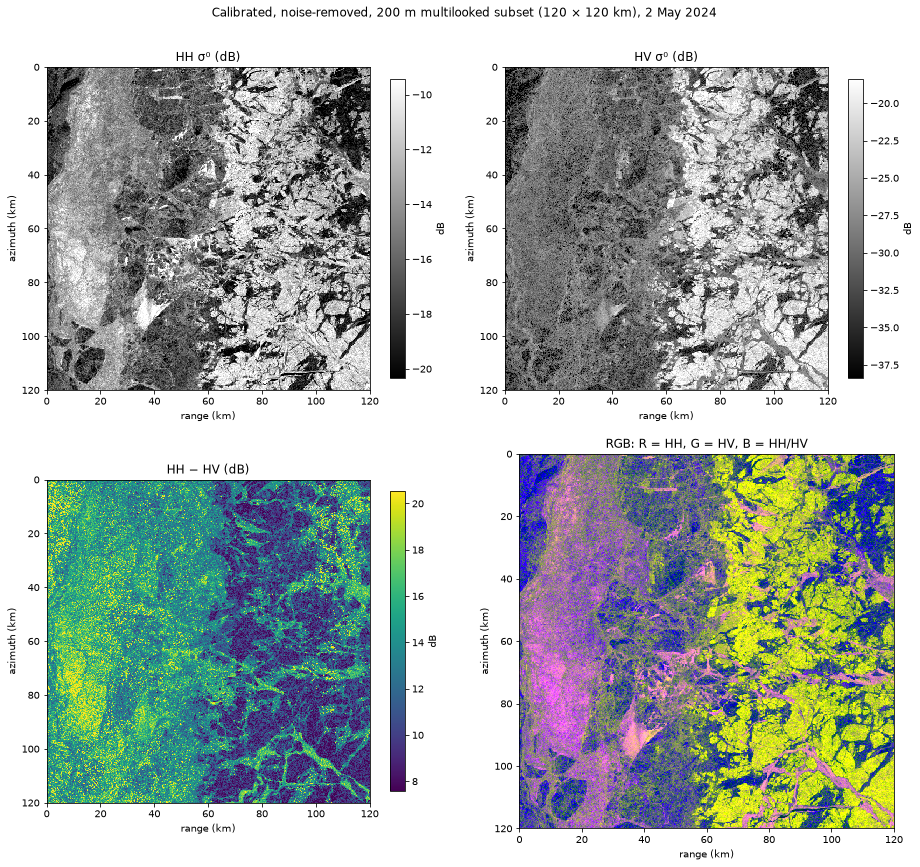

In [12]:
ratio_db = db["hh"] - db["hv"]

def stretch(x, lo=2, hi=98):
    a, b = np.nanpercentile(x, [lo, hi])
    return np.clip((x - a) / (b - a), 0, 1)

rgb = np.dstack([stretch(db["hh"]), stretch(db["hv"]), stretch(ratio_db)])
extent = [0, db['hh'].shape[1] * PIX_KM, db['hh'].shape[0] * PIX_KM, 0]

fig, axes = plt.subplots(2, 2, figsize=(13, 12))
panels = [(db["hh"], "HH σ⁰ (dB)", "gray"), (db["hv"], "HV σ⁰ (dB)", "gray"), (ratio_db, "HH − HV (dB)", "viridis")]
for ax, (arr, title, cmap) in zip(axes.flat, panels):
    vmin, vmax = np.percentile(arr, [2, 98])
    im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax, extent=extent)
    plt.colorbar(im, ax=ax, label="dB", shrink=0.8)
    ax.set_title(title)
axes[1, 1].imshow(rgb, extent=extent)
axes[1, 1].set_title("RGB: R = HH, G = HV, B = HH/HV")
for ax in axes.flat:
    ax.set_xlabel("range (km)"); ax.set_ylabel("azimuth (km)")
plt.suptitle("Calibrated, noise-removed, 200 m multilooked subset (120 × 120 km), 2 May 2024", y=1.0)
plt.tight_layout()
plt.savefig(FIGS / "04_hh_hv_ratio_rgb.png", dpi=75, bbox_inches="tight")
plt.show()

**Reading the figure** (still radar geometry: near range on the left):
- **Right half (≈ 60-120 km), yellow in the RGB:** large floes bright in *both* HH and HV, low HH − HV.
  Strong volume scattering, which is typical of **multi-year ice** (ice that has survived a summer: desalinated,
  with an air-bubble-rich upper layer). Multi-year ice drifting into the Beaufort Sea from the north
  is common in this region.
- **Dark channels between the floes, blue/dark in the RGB:** low HH and HV. Leads: open water or very
  thin new ice (nilas). SAR alone cannot tell those two apart reliably.
- **Pink channels (bright HH, low HV, high HH − HV):** surface scattering without volume scattering.
  Most likely *refrozen leads with young, rough ice* (often covered in frost flowers), but **wind-roughened
  open water** looks the same. This is exactly the ambiguity that makes ice/water classification hard.
- **Left half (0-55 km):** moderate HH, HV near the noise floor. Typical of **first-year ice** (saline, little
  volume scattering), with darker patches that may be thin ice or open water. The noisy HH − HV here is because HV is
  near the noise floor.
- Part of the left-to-right brightening in HH is not geophysical: incidence angle rises from ≈ 32° to ≈ 40° across the
  subset, which by itself lowers σ⁰ by a few dB in far range. Not corrected here (see limitations).

## 6. Histograms: what separates in this scene?

If two surface types have different backscatter, the histogram shows two peaks (bimodal), and a threshold in
the valley between them separates them. **Otsu's method** finds that valley automatically: it picks the cut that
maximizes the separation between the two groups (equivalently, minimizes the spread within each).

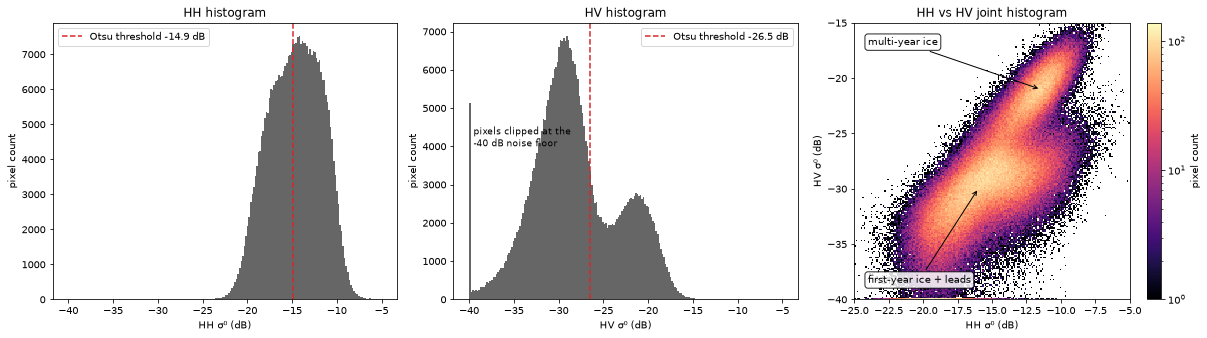

In [13]:
def otsu_threshold(x, bins=256):
    """Threshold that maximizes between-class variance of a 1-D sample (Otsu, 1979)."""
    counts, edges = np.histogram(x, bins)
    centers = (edges[:-1] + edges[1:]) / 2
    w0 = np.cumsum(counts)[:-1]                     # pixels below each candidate cut
    w1 = counts.sum() - w0                          # pixels above
    s0 = np.cumsum(counts * centers)[:-1]
    mu0, mu1 = s0 / w0, ((counts * centers).sum() - s0) / w1
    return centers[np.argmax(w0 * w1 * (mu0 - mu1) ** 2)]

otsu = {pol: otsu_threshold(db[pol].ravel()) for pol in POLS}

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for ax, pol in zip(axes, POLS):
    ax.hist(db[pol].ravel(), bins=200, range=(-40, -5), color="0.4")
    ax.axvline(otsu[pol], color="C3", ls="--", label=f"Otsu threshold {otsu[pol]:.1f} dB")
    ax.set_xlabel(f"{pol.upper()} σ⁰ (dB)"); ax.set_ylabel("pixel count"); ax.set_title(f"{pol.upper()} histogram")
    ax.legend()
axes[1].annotate("pixels clipped at the\n-40 dB noise floor", (-39.5, 4000), fontsize=9)
h = axes[2].hist2d(db["hh"].ravel(), db["hv"].ravel(), bins=200, range=[[-25, -5], [-40, -15]],
                   cmap="magma", norm=matplotlib.colors.LogNorm())
plt.colorbar(h[3], ax=axes[2], label="pixel count")
axes[2].set_xlabel("HH σ⁰ (dB)"); axes[2].set_ylabel("HV σ⁰ (dB)"); axes[2].set_title("HH vs HV joint histogram")
box = dict(boxstyle="round", fc="white", alpha=0.85)
axes[2].annotate("multi-year ice", xy=(-11.5, -21), xytext=(-24, -17), bbox=box, arrowprops=dict(arrowstyle="->"))
axes[2].annotate("first-year ice + leads", xy=(-16, -30), xytext=(-24, -38.5), bbox=box, arrowprops=dict(arrowstyle="->"))
plt.tight_layout()
plt.savefig(FIGS / "05_histograms.png", dpi=100, bbox_inches="tight")
plt.show()

**What the histograms reveal:**
- **HV is clearly bimodal** (≈ -30 dB and ≈ -21 dB). Comparing with the image, the bright mode is the **multi-year ice
  floes**, the dark mode is **first-year ice plus leads**, which all sit near the HV noise floor.
- **HH is essentially unimodal**: no clean valley at all.
- **Open water / new ice is not a separate peak.** It is a small tail at low HH (≈ the darkest 5 %). This is early May
  at roughly -15 °C air temperature: leads that open refreeze within hours, so real open water is scarce.

So the dominant natural split in this scene is *old ice vs. young ice*, **not** ice vs. water. Any method that just
"finds two groups" will find that split. That's the key lesson for the classification below.

## 7. Ice vs. open water / thin ice

We call the target class **"dark leads"** = open water *or* very thin new ice (nilas): both are smooth and dark in
HH and HV, and C-band SAR alone cannot reliably separate them.

### (a) Threshold
First the naive version: Otsu on HV.

In [14]:
naive_water = db["hv"] < otsu["hv"]
print(f"Otsu on HV ({otsu['hv']:.1f} dB) labels {naive_water.mean():.0%} of the subset as 'water'. "
      "That is the first-year ice, not water.")

Otsu on HV (-26.5 dB) labels 68% of the subset as 'water'. That is the first-year ice, not water.


That's clearly wrong. Instead: a threshold on **HH** picking out the dark tail. Dark leads (calm water or nilas) are
specular reflectors and much darker in HH than any snow-covered ice. The value **-19 dB was chosen by hand** by
inspecting the histogram tail and the image (it is not derived from a model), so below we check how sensitive the
result is to that choice.

In [15]:
HH_THRESHOLD = -19.0
water_thr = db["hh"] < HH_THRESHOLD
print(f"HH < {HH_THRESHOLD} dB: {water_thr.mean():.1%} dark leads")

for t in [-21, -20, -19, -18, -17]:
    print(f"  threshold {t:>4} dB -> dark-lead fraction {np.mean(db['hh'] < t):5.1%}")

HH < -19.0 dB: 7.5% dark leads
  threshold  -21 dB -> dark-lead fraction  0.9%
  threshold  -20 dB -> dark-lead fraction  3.0%
  threshold  -19 dB -> dark-lead fraction  7.5%
  threshold  -18 dB -> dark-lead fraction 14.6%
  threshold  -17 dB -> dark-lead fraction 23.6%


The fraction roughly doubles for each dB the threshold moves: the result depends strongly on a hand-chosen number.
Worth remembering when interpreting it.

### (b) k-means clustering
k-means groups pixels into *k* clusters in feature space (here: HH dB, HV dB) by minimizing distance to cluster centres.
It is unsupervised: it knows nothing about ice or water, so **we have to name the clusters afterwards.** Both features
are in dB with similar spread, so they are not rescaled. The model is fitted on every 7th pixel for speed, then applied
to all pixels.

In [16]:
from sklearn.cluster import KMeans

X = np.column_stack([db["hh"].ravel(), db["hv"].ravel()])

def kmeans_labels(k):
    """Fit k-means; return labels reordered so cluster 0 has the darkest HH centre, and the sorted centres."""
    km = KMeans(n_clusters=k, n_init=4, random_state=0).fit(X[::7])
    order = np.argsort(km.cluster_centers_[:, 0])
    rank = np.argsort(order)                    # old label -> rank by HH brightness
    return rank[km.predict(X)].reshape(db["hh"].shape), km.cluster_centers_[order]

labels2, centers2 = kmeans_labels(2)
labels4, centers4 = kmeans_labels(4)
for k, c, lab in [(2, centers2, labels2), (4, centers4, labels4)]:
    print(f"k={k} cluster centres (HH, HV dB), darkest first:")
    for i, (chh, chv) in enumerate(c):
        print(f"   {i}: ({chh:6.1f}, {chv:6.1f})  {np.mean(lab == i):5.1%} of pixels")

water_km = labels4 == 0   # darkest of 4 clusters = dark leads

k=2 cluster centres (HH, HV dB), darkest first:
   0: ( -16.1,  -31.0)  64.6% of pixels
   1: ( -12.0,  -22.8)  35.4% of pixels
k=4 cluster centres (HH, HV dB), darkest first:
   0: ( -18.7,  -35.1)  15.1% of pixels
   1: ( -16.2,  -30.5)  31.5% of pixels
   2: ( -13.3,  -27.4)  30.9% of pixels
   3: ( -11.5,  -20.9)  22.4% of pixels


- **k = 2** splits multi-year ice (≈ -12 / -23 dB) from everything else, same as Otsu on HV. Not ice vs. water.
- **k = 4**: the darkest cluster (lowest HH *and* HV) is our candidate "dark leads" class.

Dark-lead fraction: threshold 7.5%, k-means 15.1%
Pixel agreement 90.4% | overlap of the dark-lead class (intersection over union) 0.40
Of the threshold's dark-lead pixels, k-means also flags 87%


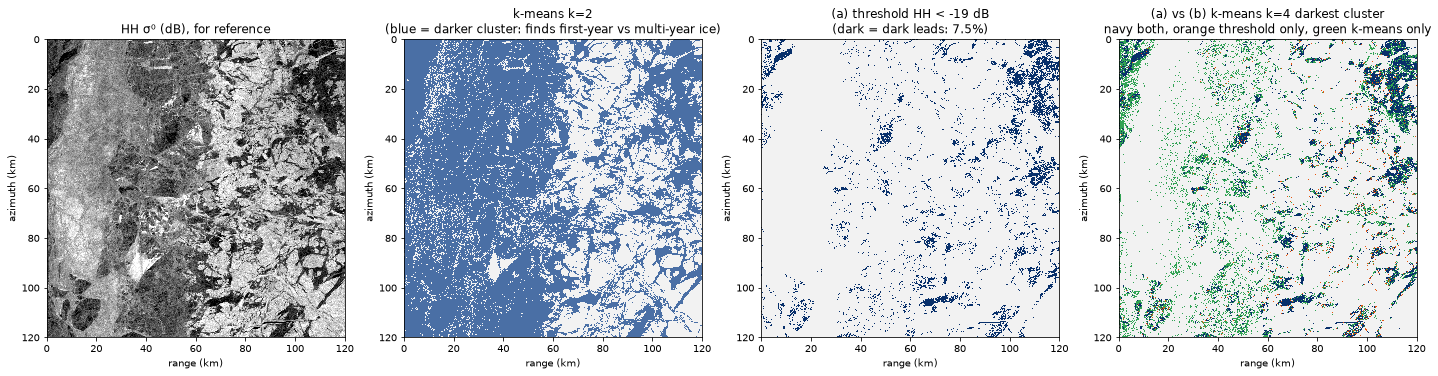

In [17]:
agree = np.mean(water_thr == water_km)
both = np.sum(water_thr & water_km)
iou = both / np.sum(water_thr | water_km)
print(f"Dark-lead fraction: threshold {water_thr.mean():.1%}, k-means {water_km.mean():.1%}")
print(f"Pixel agreement {agree:.1%} | overlap of the dark-lead class (intersection over union) {iou:.2f}")
print(f"Of the threshold's dark-lead pixels, k-means also flags {both / water_thr.sum():.0%}")
# Note: 90 % pixel agreement sounds high but is mostly the two methods agreeing on "ice", which is ~85-93 % of the
# image anyway. Intersection over union of the dark-lead class itself is the more honest number.

fig, axes = plt.subplots(1, 4, figsize=(20, 5.4))
axes[0].imshow(db["hh"], cmap="gray", vmin=-21, vmax=-9, extent=extent); axes[0].set_title("HH σ⁰ (dB), for reference")
axes[1].imshow(labels2, cmap=ListedColormap(["#4a6fa5", "#f2f2f2"]), extent=extent)
axes[1].set_title("k-means k=2\n(blue = darker cluster: finds first-year vs multi-year ice)")
axes[2].imshow(water_thr, cmap=ListedColormap(["#f2f2f2", "#08306b"]), extent=extent)
axes[2].set_title(f"(a) threshold HH < {HH_THRESHOLD:.0f} dB\n(dark = dark leads: {water_thr.mean():.1%})")
diff = np.select([water_thr & water_km, water_thr & ~water_km, ~water_thr & water_km], [1, 2, 3], 0)
axes[3].imshow(diff, cmap=ListedColormap(["#f2f2f2", "#08306b", "#e6550d", "#31a354"]), extent=extent, interpolation="nearest")
axes[3].set_title("(a) vs (b) k-means k=4 darkest cluster\nnavy both, orange threshold only, green k-means only")
for ax in axes:
    ax.set_xlabel("range (km)"); ax.set_ylabel("azimuth (km)")
plt.tight_layout()
plt.savefig(FIGS / "06_classification.png", dpi=90, bbox_inches="tight")
plt.show()

**Comparing (a) and (b):**
- Both find the same main lead systems (navy): the network between the multi-year floes on the right and the
  flaw-lead edge on the left. 87 % of the threshold's dark-lead pixels are also in the darkest k-means cluster.
- k-means flags about twice as much (15 % vs 7.5 %). The extra (green) pixels are mostly darker first-year ice in
  near range (left), where HV sits at the noise floor. k-means draws its boundary wherever the data happen to cluster,
  not where the physics says water ends.
- Neither method knows what water is. The threshold encodes a human judgement (one number); k-means needs a human to
  pick *k* and name the clusters. With k = 2 it found ice *types*, not ice vs. water.


## 8. Comparison with an independent reference: AMSR2 sea ice concentration

**Reference:** University of Bremen ASI algorithm applied to AMSR2 89 GHz passive microwave data, daily, 6.25 km grid
(Spreen et al., 2008; https://seaice.uni-bremen.de). Free, no login. Passive microwave measures the natural microwave
*emission* of the surface (no radar), which is very different between ice and water, so it is independent of our SAR.
Values are concentration in % (120 = land).

**Making them comparable:** our classification is in radar geometry at 200 m; AMSR2 is a map grid at 6.25 km. So:
1. Get latitude/longitude for every 200 m pixel by interpolating the GCPs.
2. Project those to the AMSR2 map projection (NSIDC polar stereographic, EPSG:3413) and find which 6.25 km cell each falls in.
3. Per AMSR2 cell: SAR ice fraction = 1 - (share of dark-lead pixels). Only cells ≥ 90 % covered by our subset are kept.

In [18]:
from scipy.interpolate import griddata
from rasterio.warp import transform as warp_transform

AMSR2_FILE = DATA / "asi-AMSR2-n6250-20240502-v5.4.tif"
if not AMSR2_FILE.exists():
    import urllib.request
    urllib.request.urlretrieve("https://data.seaice.uni-bremen.de/amsr2/asi_daygrid_swath/n6250/2024/may/Arctic/"
                               "asi-AMSR2-n6250-20240502-v5.4.tif", AMSR2_FILE)
with rasterio.open(AMSR2_FILE) as src:
    amsr2_raw = src.read(1)
    amsr2_crs, amsr2_tf = src.crs, src.transform
amsr2 = amsr2_raw.astype("float32")
amsr2[(amsr2_raw == 0) | (amsr2_raw > 100)] = np.nan   # 0 = no data (file's nodata value), 120 = land

# 1. lat/lon of each 200 m pixel centre (in full-image coordinates) from the GCP grid
g_rc = np.array([[g.row, g.col] for g in gcps]); g_lat = np.array([g.y for g in gcps]); g_lon = np.array([g.x for g in gcps])
n = db["hh"].shape[0]
rr, cc = np.meshgrid(ROW0 + LOOKS * np.arange(n) + LOOKS / 2, COL0 + LOOKS * np.arange(n) + LOOKS / 2, indexing="ij")
lat = griddata(g_rc, g_lat, (rr, cc), method="linear")
lon = griddata(g_rc, g_lon, (rr, cc), method="linear")

# 2. project to EPSG:3413 and find the AMSR2 cell (row, col) of each pixel
x, y = warp_transform("EPSG:4326", amsr2_crs, lon.ravel(), lat.ravel())
a_col, a_row = ~amsr2_tf * (np.array(x), np.array(y))
cell = a_row.astype(int) * amsr2.shape[1] + a_col.astype(int)

# 3. per-cell fractions
full_cell = (6250 / (PIX_KM * 1000)) ** 2      # ~977 SAR pixels fill one AMSR2 cell
cells, inverse, count = np.unique(cell, return_inverse=True, return_counts=True)
keep = count >= 0.9 * full_cell
comparison = {}
for name, mask in [("threshold", water_thr), ("k-means", water_km)]:
    sar_ice = 100 * (1 - np.bincount(inverse, weights=mask.ravel()) / count)
    comparison[name] = sar_ice[keep]
ref = amsr2.ravel()[cells[keep]]
ok = ~np.isnan(ref)
print(f"{ok.sum()} AMSR2 cells fully covered by the subset")
print(f"AMSR2 SIC in those cells: mean {ref[ok].mean():.1f} %, min {ref[ok].min():.0f} %")
for name, v in comparison.items():
    d = v[ok] - ref[ok]
    print(f"SAR {name:9s}: ice fraction mean {v[ok].mean():.1f} %, min {v[ok].min():.0f} % | "
          f"SAR - AMSR2: mean {d.mean():+.1f}, RMS {np.sqrt(np.mean(d**2)):.1f} percentage points, "
          f"correlation {np.corrcoef(v[ok], ref[ok])[0, 1]:.2f}")

336 AMSR2 cells fully covered by the subset
AMSR2 SIC in those cells: mean 100.0 %, min 98 %
SAR threshold: ice fraction mean 92.9 %, min 37 % | SAR - AMSR2: mean -7.0, RMS 12.2 percentage points, correlation 0.09
SAR k-means  : ice fraction mean 85.8 %, min 22 % | SAR - AMSR2: mean -14.2, RMS 20.0 percentage points, correlation 0.08


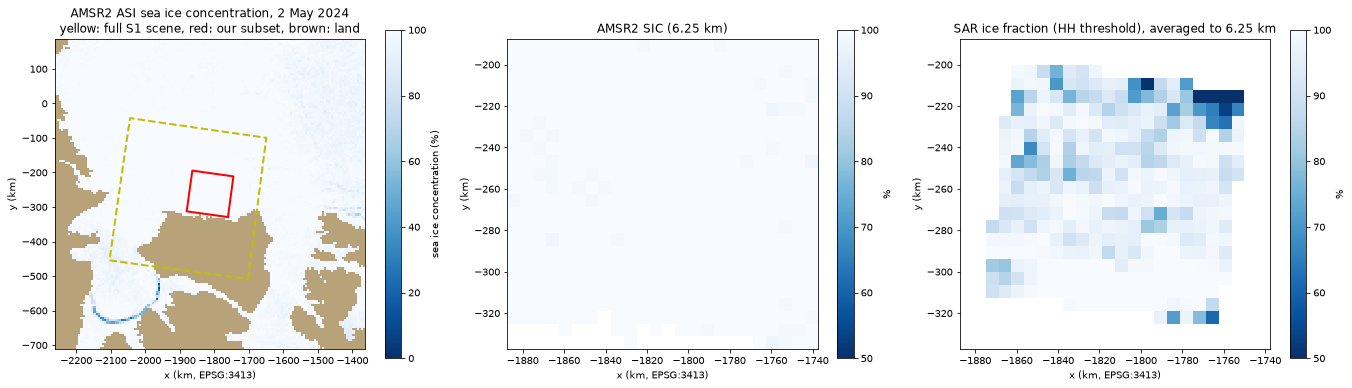

In [19]:
# Map view: AMSR2 around the scene, with the full scene and our subset outlined.
def footprint(rows, cols):
    """Outline (x, y in EPSG:3413) of a rectangle of full-image pixel coordinates."""
    r = np.r_[np.full(50, rows[0]), np.linspace(*rows, 50), np.full(50, rows[1]), np.linspace(*rows[::-1], 50)]
    c = np.r_[np.linspace(*cols, 50), np.full(50, cols[1]), np.linspace(*cols[::-1], 50), np.full(50, cols[0])]
    la = griddata(g_rc, g_lat, (r, c), method="linear"); lo = griddata(g_rc, g_lon, (r, c), method="linear")
    return warp_transform("EPSG:4326", amsr2_crs, lo, la)

# SAR ice fraction on the AMSR2 grid, for plotting
sar_grid = np.full(amsr2.size, np.nan)
sar_grid[cells[keep]] = comparison["threshold"]
sar_grid = sar_grid.reshape(amsr2.shape)
r_idx, c_idx = np.unravel_index(cells[keep], amsr2.shape)
win = (slice(r_idx.min() - 2, r_idx.max() + 3), slice(c_idx.min() - 2, c_idx.max() + 3))

def grid_extent(rows, cols):
    x0, y0 = amsr2_tf * (cols.start, rows.start); x1, y1 = amsr2_tf * (cols.stop, rows.stop)
    return [x0 / 1e3, x1 / 1e3, y1 / 1e3, y0 / 1e3]

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
region = (slice(win[0].start - 60, win[0].stop + 60), slice(win[1].start - 60, win[1].stop + 60))
land = np.where(amsr2_raw[region] == 120, 1.0, np.nan)
cmap_sic = plt.get_cmap("Blues_r").copy(); cmap_sic.set_bad("white")
im = axes[0].imshow(amsr2[region], cmap=cmap_sic, vmin=0, vmax=100, extent=grid_extent(*region), origin="upper")
axes[0].imshow(land, cmap=ListedColormap(["#b8a27a"]), extent=grid_extent(*region), origin="upper")
for (rows, cols), style in [(((0, FULL_SHAPE[0] - 1), (0, FULL_SHAPE[1] - 1)), "y--"), (((ROW0, ROW0 + SIZE), (COL0, COL0 + SIZE)), "r-")]:
    fx, fy = footprint(rows, cols)
    axes[0].plot(np.array(fx) / 1e3, np.array(fy) / 1e3, style, lw=2)
axes[0].set_title("AMSR2 ASI sea ice concentration, 2 May 2024\nyellow: full S1 scene, red: our subset, brown: land")
plt.colorbar(im, ax=axes[0], label="sea ice concentration (%)", shrink=0.8)
for ax, arr, title in [(axes[1], amsr2[win], "AMSR2 SIC (6.25 km)"),
                       (axes[2], sar_grid[win], f"SAR ice fraction (HH threshold), averaged to 6.25 km")]:
    im = ax.imshow(arr, cmap=cmap_sic, vmin=50, vmax=100, extent=grid_extent(*win))
    ax.set_title(title); plt.colorbar(im, ax=ax, label="%", shrink=0.8)
for ax in axes:
    ax.set_xlabel("x (km, EPSG:3413)"); ax.set_ylabel("y (km)")
plt.tight_layout()
plt.savefig(FIGS / "07_amsr2_comparison.png", dpi=90, bbox_inches="tight")
plt.show()

**What the comparison shows:**
- **AMSR2 says ~100 % ice everywhere in the subset** (all cells 98-100 %). The SAR methods say 93 % (threshold) and
  86 % (k-means) on average, with a few cells down to 22-37 % where large dark leads are.
- **Correlation is near zero (≈ 0.1), but that mostly says AMSR2 has almost no variation here**, so there is nothing
  to correlate with. The useful number is the bias: SAR shows 7-14 percentage points *less* ice.

**Which is right?** Probably neither is simply "wrong". Plausible reasons, which this single comparison cannot separate:
1. **The dark leads are mostly thin new ice, not open water.** At about -15 °C in early May, leads refreeze within hours.
   Nilas is dark to C-band SAR (smooth, saline surface), but its 89 GHz microwave *emission* becomes ice-like once it is
   a few centimetres thick (only the very thinnest ice pulls AMSR2 concentrations down), so AMSR2 largely counts it as
   ice. If so, our "dark leads" class is really "open water *or thin ice*", which we said up front.
2. **Resolution:** AMSR2's 89 GHz footprint is several km; narrow leads are averaged in with surrounding ice, and ASI
   concentrations near 100 % carry several % uncertainty.
3. **Timing:** the SAR image is a snapshot at 15:20 UTC; AMSR2 is a daily average of several overpasses.
4. **Our own errors:** the threshold is hand-picked (7.5 % ± a factor of two for ±1 dB), k-means over-flags
   near-range first-year ice, and incidence angle is not corrected.

A Canadian Ice Service chart for the same week (which reports ice *stage of development*, including new/nilas
ice) would be the natural next check on explanation 1.

## 9. Summary and limitations

- Calibrated, thermal-noise-corrected σ⁰ from raw Sentinel-1 EW GRD DN using ESA's annotation LUTs.
- HV is near the instrument noise floor over first-year ice and leads; noise removal fixes most of the sub-swath
  banding, but a ~1.5 dB step remains at the EW3/EW4 boundary.
- In this early-May scene the dominant backscatter contrast is **multi-year vs. first-year ice**, not ice vs. water.
  Naive data-driven splits (Otsu on HV, k-means k=2) find that contrast.
- Dark leads (open water *or* thin new ice): 7.5 % (HH threshold) to 15 % (k-means) of the subset.
- AMSR2 shows ~100 % ice; the disagreement is most plausibly thin ice that SAR sees as dark but passive microwave
  counts as ice, plus resolution and timing differences.

**Limitations:** one scene, one 120 × 120 km subset, no ground truth; hand-picked threshold with strong sensitivity;
incidence angle not corrected (32-40° across the subset); open water and nilas not separable here; wind-roughened
water could be classified as ice; residual HV noise; GCP-interpolation geolocation (no terrain correction, fine over
sea ice but not survey-grade).